# Notebook 6: Capstone — Passive Hinge Impedance Control

## From Tendon API to Impedance Control Through a Cable

In Notebook 5 we learned how MuJoCo spatial tendons work: site-based routing,
`data.ten_length`, and tension-only behaviour via `springlength`. Now we use these
concepts to build an impedance controller for a more complex system.

### The Capstone Geometry

The capstone model (`tendon_block_hinge.xml`) connects three bodies through a cable:

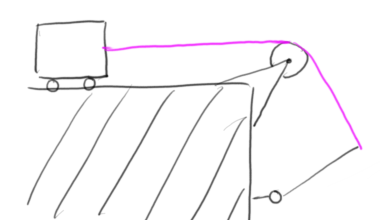

- A **block** slides along a ceiling rail at z=1.5 (prismatic joint, `block_slide`)
- A **fixed corner pulley** directly above the pendulum tip redirects the cable
- A **pendulum** (same geometry as `pendulum.xml`) swings about a hinge joint (`hinge`)

The controller reads `data.qpos[hinge]` (pendulum angle) as the controlled variable but actuates the block. Force is transmitted **indirectly** through the cable spring: block position → cable stretch → cable tension
→ torque at pendulum tip. The hinge joint itself has no actuator in this (passive) scenario.

### Passive vs Assisted

This notebook is the **passive** scenario: the hinge has no external torque (`ctrl[1] = 0`).
The controller achieves pendulum tracking entirely through cable-transmitted force.
In Notebook 7, we add a proportional hinge assist torque and observe improved tracking.

## Setup

In [1]:
import dms
import mediapy
import tempfile
import mujoco
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print(f"MuJoCo version: {mujoco.__version__}")

MuJoCo version: 3.6.0


## Load Model and Extract Named Indices

In [ ]:
# Load the shared capstone model (validated in Plan 01)
model_path =  dms.get_asset_path('mujoco_models/tendon_block_hinge.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data  = mujoco.MjData(model)

print(f"nq={model.nq}, nv={model.nv}, nu={model.nu}, ntendon={model.ntendon}")
print(f"timestep={model.opt.timestep} s")

# Extract named joint indices (robust to model reordering)
hinge_qpos_idx = model.joint("hinge").qposadr[0]        # index into data.qpos
hinge_vel_idx  = model.joint("hinge").dofadr[0]         # index into data.qvel
block_slide_idx = model.joint("block_slide").qposadr[0]  # index into data.qpos
block_vel_idx  = model.joint("block_slide").dofadr[0]    # index into data.qvel

# Extract named actuator indices
block_ctrl_idx = model.actuator("block_motor").id        # ctrl[0]: block force (N)
hinge_ctrl_idx = model.actuator("hinge_motor").id        # ctrl[1]: hinge torque (Nm)

print(f"\nhinge_qpos_idx={hinge_qpos_idx}, hinge_vel_idx={hinge_vel_idx}")
print(f"block_slide_idx={block_slide_idx}, block_vel_idx={block_vel_idx}")
print(f"block_ctrl_idx={block_ctrl_idx}, hinge_ctrl_idx={hinge_ctrl_idx}")

## Read Tendon Parameters from Model

In [11]:
# Read cable stiffness and natural length from model at runtime
tendon_id       = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_TENDON, "cable")
L_natural       = model.tendon_lengthspring[tendon_id, 1]   # springlength upper bound
CABLE_STIFFNESS = model.tendon_stiffness[tendon_id]          # N/m

print(f"Cable: L_natural={L_natural:.4f} m, stiffness={CABLE_STIFFNESS:.1f} N/m")
print(f"Tension formula: T = {CABLE_STIFFNESS:.0f} * max(0, ten_length - {L_natural:.4f})")

Cable: L_natural=1.7810 m, stiffness=200.0 N/m
Tension formula: T = 200 * max(0, ten_length - 1.7810)


## Theory: Impedance Control Through a Cable Spring

### Impedance Law at the Hinge Joint

The desired behaviour is a virtual spring-damper impedance at the pendulum hinge:

$$\tau_{imp} = K(\theta_d - \theta) + D(\dot{\theta}_d - \dot{\theta})$$

### Two-Level Control Structure

Unlike direct-drive actuation, the cable is a **passive spring** — it cannot directly
command torque. The cable tension arises from block position, not block force.
This creates a two-level control structure:

**Outer loop (hinge impedance → desired cable tension):**

The total torque the cable must deliver at the hinge is:

$$\tau_{total} = \tau_{imp} + \tau_{gravity}$$

where $\tau_{gravity}$ = `data.qfrc_bias[hinge_dof]`. In passive mode the cable is
the only torque source, so it must provide both impedance tracking and gravity
compensation.

The cable tension $T$ produces a torque at the hinge via the moment arm:

$$\tau_{cable} = r_{eff}(\theta) \cdot T$$

where $r_{eff}(\theta)$ is the **signed effective moment arm**, computed at each
timestep from the cross product of the moment arm and cable direction:

$$r_{eff} = (\mathbf{r} \times \hat{\mathbf{f}}) \cdot \hat{y}$$

with $\mathbf{r}$ = tip − pivot and $\hat{\mathbf{f}}$ = unit vector from tip toward
corner pulley. This varies with $\theta$ as the cable angle changes.

Setting $\tau_{cable} = \tau_{total}$ and solving for $T$:

$$T_{desired} = \max\!\left(0,\; \frac{\tau_{total}}{r_{eff}(\theta)}\right)$$

The $\max(0, \cdot)$ reflects that the cable is tension-only.

**Inner loop (desired cable tension → desired block position → block PD):**

$$L_{desired} = \frac{T_{desired}}{k} + L_{natural}$$

$$x_{block,desired} = 1.5 - (L_{desired} - L_{seg2}(\theta))$$

$$F_{block} = K_{block}(x_{desired} - x_{block}) + D_{block}(0 - \dot{x}_{block})$$

where $L_{seg2}(\theta)$ is the current corner-pulley-to-tip distance,
and `1.5` is the block-anchor-to-corner horizontal distance when block_slide is at 0.

### Block Motor Sign Convention

The `block_slide` joint axis = $+X$.
Block starts at $x = -1$ (left of corner pulley at $x = 0.5$).
Positive `ctrl[0]` pushes block in $+X$ → cable shortens → **slack**.
The inner loop uses position control, so the sign is handled automatically.

## Controller Implementation

In [15]:
# Controller parameters
K        = 50.0    # Nm/rad -- hinge impedance stiffness
D        = 10.0    # Nm*s/rad -- hinge impedance damping
L_ROD    = 0.5     # m -- pendulum rod length (pivot to tip)

# Corner pulley world position (from XML)
CORNER_X = 0.5
CORNER_Z = 1.5
# Pivot world position
PIVOT_X  = 0.0
PIVOT_Z  = 1.0

# Block-to-corner horizontal distance at block_slide=0
# Block starts at x=-1, corner at x=0.5 → distance = 1.5
SEG1_AT_ZERO = 1.5

# Inner-loop block position PD gains
K_BLOCK  = 2000.0  # N/m -- block position stiffness
D_BLOCK  = 50.0    # N*s/m -- block velocity damping


def compute_r_eff(q):
    """Signed effective moment arm: Y-component of (r x f_hat).

    r     = tip - pivot  (moment arm vector in XZ plane)
    f_hat = unit vector from tip toward corner pulley (cable direction)

    Returns a scalar. For this geometry r_eff < 0 (cable opposes positive rotation),
    so tau_total / r_eff naturally gives positive T when tau_total < 0.
    """
    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)

    # Moment arm (pivot to tip)
    r_x = tip_x - PIVOT_X      # = L_ROD * cos(q)
    r_z = tip_z - PIVOT_Z      # = -L_ROD * sin(q)

    # Cable direction (tip toward corner)
    dx = CORNER_X - tip_x
    dz = CORNER_Z - tip_z
    d  = np.sqrt(dx**2 + dz**2)
    f_x = dx / d
    f_z = dz / d

    # Y-component of r x f_hat  (3D cross product, consistent with MuJoCo hinge axis)
    return r_z * f_x - r_x * f_z


def capstone_controller(model, data, q_des, dq_des, tau_hinge=0.0):
    """Two-level impedance controller for the capstone tendon-pendulum system.

    Outer loop: hinge angle impedance -> desired cable tension.
    Inner loop: cable tension -> desired cable length -> desired block position -> block PD.

    Args:
        model:      MjModel instance
        data:       MjData instance (read-write: sets data.ctrl)
        q_des:      desired hinge angle (rad)
        dq_des:     desired hinge angular velocity (rad/s)
        tau_hinge:  hinge motor torque (Nm): 0.0 = passive, >0 = assisted
    """
    # --- OUTER LOOP: hinge impedance ---
    q  = data.qpos[hinge_qpos_idx].copy()   # current hinge angle
    dq = data.qvel[hinge_vel_idx].copy()     # current hinge angular velocity

    # Impedance torque + gravity compensation at the hinge joint
    tau_imp   = K * (q_des - q) + D * (dq_des - dq)
    tau_grav  = data.qfrc_bias[hinge_vel_idx]     # gravity bias to compensate
    tau_total = tau_imp + tau_grav

    # Effective moment arm from cross product (angle-dependent)
    r_eff = compute_r_eff(q)

    # Required cable tension: tau_total = r_eff * T  →  T = tau_total / r_eff
    # Cable is tension-only: clamp to >= 0
    T_desired = max(0.0, tau_total / r_eff)

    # --- INNER LOOP: block position PD ---
    # Required cable length to achieve T_desired via passive cable spring
    L_desired = T_desired / CABLE_STIFFNESS + L_natural

    # Corner-pulley-to-tip distance at current hinge angle (segment 2)
    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)
    seg2  = np.sqrt((tip_x - CORNER_X)**2 + (tip_z - CORNER_Z)**2)

    # Desired block position (from cable geometry: seg1 = SEG1_AT_ZERO - block_qpos)
    seg1_desired  = L_desired - seg2
    block_x_des   = np.clip(SEG1_AT_ZERO - seg1_desired, -1.0, 0.5)

    # PD control on block position
    block_x  = data.qpos[block_slide_idx].copy()
    block_xd = data.qvel[block_vel_idx].copy()
    F_block  = K_BLOCK * (block_x_des - block_x) + D_BLOCK * (0.0 - block_xd)

    # Apply actuator commands
    data.ctrl[block_ctrl_idx] = np.clip(F_block, -100.0, 100.0)
    data.ctrl[hinge_ctrl_idx] = tau_hinge


def get_cable_tension(data, tendon_idx=0):
    """Compute analytical cable tension from current tendon length.

    Returns: cable tension in Newtons (zero when cable is slack).
    """
    stretch = float(data.ten_length[tendon_idx]) - L_natural
    return CABLE_STIFFNESS * max(0.0, stretch)


# Verify r_eff at theta=0
r_eff_0 = compute_r_eff(0.0)
print("Controller ready.")
print(f"  Hinge impedance: K={K} Nm/rad, D={D} Nm*s/rad")
print(f"  Block PD:        K_BLOCK={K_BLOCK} N/m, D_BLOCK={D_BLOCK} N*s/m")
print(f"  Rod length:      L_ROD={L_ROD} m")
print(f"  r_eff at theta=0: {r_eff_0:.3f} m")

Controller ready.
  Hinge impedance: K=50.0 Nm/rad, D=10.0 Nm*s/rad
  Block PD:        K_BLOCK=2000.0 N/m, D_BLOCK=50.0 N*s/m
  Rod length:      L_ROD=0.5 m
  r_eff at theta=0: -0.500 m


## Experiment: Sinusoidal Trajectory Tracking (Passive Hinge)

### Desired Trajectory

$$\theta_d(t) = A \sin(2\pi f t), \quad \dot{\theta}_d(t) = A \cdot 2\pi f \cos(2\pi f t)$$

with $A = 0.3$ rad ($\approx 17°$) and $f = 0.5$ Hz.

### Passive Condition

The hinge motor torque is zero: $\tau_{hinge} = 0$ (passive scenario). All pendulum
torque is transmitted through the cable.

In [ ]:
# Trajectory parameters
A_des   = 0.3          # rad (~17 degrees)
f_des   = 0.5          # Hz
omega_d = 2 * np.pi * f_des

# Simulation parameters
sim_duration = 5.0
dt           = model.opt.timestep
n_steps      = int(sim_duration / dt)

TAU_HINGE_PASSIVE = 0.0  # no hinge torque for passive scenario

# Reset and initialise
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

# Pre-allocate recording arrays (record-then-plot convention)
t_hist  = np.zeros(n_steps)
q_hist  = np.zeros(n_steps)   # actual hinge angle (rad)
qd_hist = np.zeros(n_steps)   # desired hinge angle (rad)
F_hist  = np.zeros(n_steps)   # cable tension (N)
frames= []
# Simulation loop
renderer= mujoco.Renderer(model)
camera=camera=dms.mujoco.make_camera(model)
for i in range(n_steps):
    t = data.time

    # Desired trajectory
    q_des  = A_des * np.sin(omega_d * t)
    dq_des = A_des * omega_d * np.cos(omega_d * t)

    # Record BEFORE stepping
    t_hist[i]  = t
    q_hist[i]  = data.qpos[hinge_qpos_idx].copy()
    qd_hist[i] = q_des
    F_hist[i]  = get_cable_tension(data)

    # Apply controller
    capstone_controller(model, data, q_des, dq_des, tau_hinge=TAU_HINGE_PASSIVE)

    # Advance simulation
    mujoco.mj_step(model, data)
    renderer.update_scene(data, camera=camera)
    frames.append(renderer.render().copy())
renderer.close()
mediapy.show_video(frames, fps=int(1/dt))
# Compute RMS tracking error
rms_rad = np.sqrt(np.mean((q_hist - qd_hist)**2))
rms_deg = np.degrees(rms_rad)
PASSIVE_RMS_DEG = rms_deg   # save for NB7 reference

print(f"Passive scenario simulation: {sim_duration} s ({n_steps} steps)")
print(f"  Hinge range: [{np.degrees(q_hist.min()):.1f}, {np.degrees(q_hist.max()):.1f}] degrees")
print(f"  Max cable tension: {F_hist.max():.2f} N")
print()
print(f"Passive scenario RMS tracking error: {rms_deg:.2f} degrees")

assert rms_deg < 5.0, (
    f"RMS tracking error {rms_deg:.2f} deg exceeds 5 deg threshold."
)
print(f"  PASS: RMS < 5 degrees")

This browser does not support the video tag.


Passive scenario simulation: 5.0 s (5000 steps)
  Hinge range: [-16.7, 17.8] degrees
  Max cable tension: 12.96 N

Passive scenario RMS tracking error: 1.13 degrees
  PASS: RMS < 5 degrees


## Results: Angle Tracking and Cable Tension

The two-panel figure shows:
1. **Hinge angle tracking** — desired (dashed) vs actual (solid)
2. **Cable tension** — the cable tension oscillates as the controller adjusts block position

The cable is tension-only, so tension is zero whenever the desired torque is positive
(i.e., when the controller wants to push the pendulum downward — the cable can only pull upward).

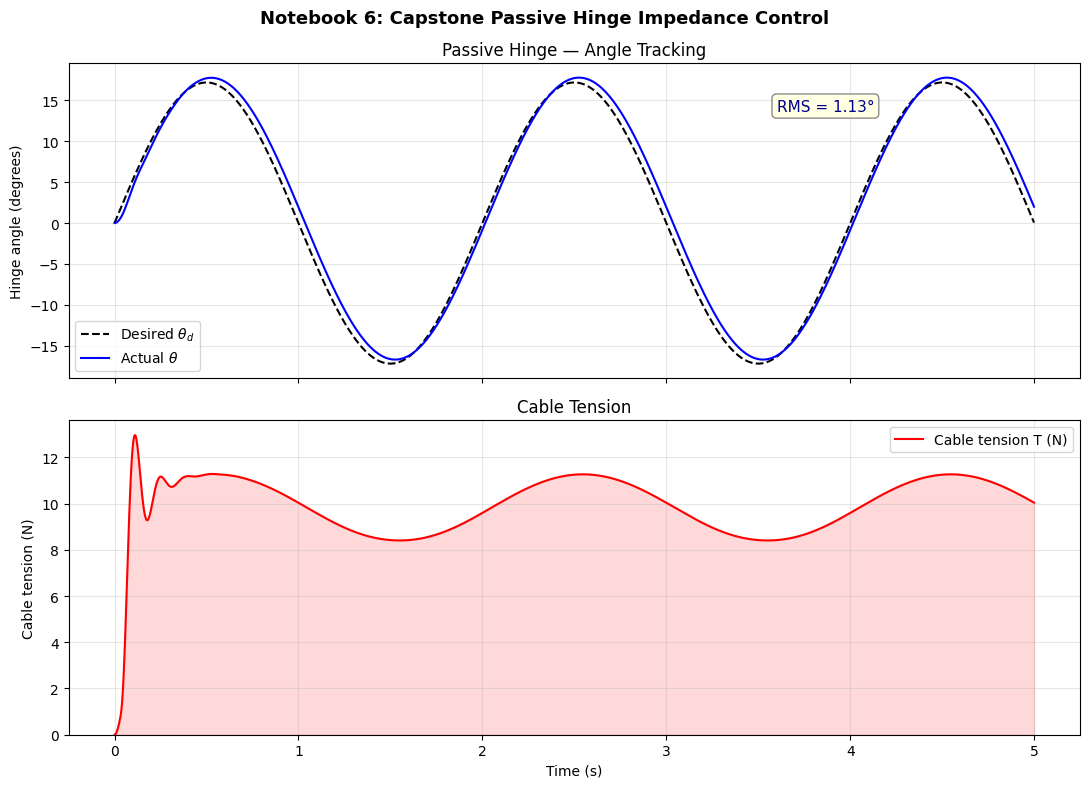

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# --- Top panel: Hinge angle tracking ---
ax = axes[0]
ax.plot(t_hist, np.degrees(qd_hist), 'k--', lw=1.5, label='Desired $\\theta_d$')
ax.plot(t_hist, np.degrees(q_hist),  'b-',  lw=1.5, label='Actual $\\theta$')
ax.set_ylabel('Hinge angle (degrees)')
ax.set_title('Passive Hinge — Angle Tracking')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(
    f'RMS = {rms_deg:.2f}°',
    xy=(t_hist[-1] * 0.72, np.degrees(A_des) * 0.80),
    fontsize=11, color='darkblue',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.9)
)

# --- Bottom panel: Cable tension ---
ax = axes[1]
ax.plot(t_hist, F_hist, 'r-', lw=1.5, label='Cable tension T (N)')
ax.fill_between(t_hist, F_hist, 0, alpha=0.15, color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cable tension (N)')
ax.set_title('Cable Tension')
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Notebook 6: Capstone Passive Hinge Impedance Control', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### Key Results

| Metric | Value |
|--------|-------|
| Trajectory amplitude | 0.3 rad (17°), 0.5 Hz |
| Controller | Two-level: hinge impedance (K=50, D=10) + block position PD |
| Passive RMS error | see output above |
| Threshold | < 5° |

### What We Built

1. **Two-level controller:** Outer loop computes desired cable tension from hinge
   impedance; inner loop converts to desired cable length and then desired block
   position using inverse kinematics of the cable geometry.
2. **Dynamic moment arm:** The effective moment arm $r_{eff}(\theta)$ is computed
   at each timestep via the cross product $(\mathbf{r} \times \hat{\mathbf{f}}) \cdot \hat{y}$,
   so the tension-to-torque mapping stays accurate as the pendulum swings.
3. **Gravity compensation:** `data.qfrc_bias[hinge_dof]` is included in $\tau_{total}$
   so the cable automatically provides both gravity compensation and impedance tracking.
   In passive mode the cable is the sole torque source — it must handle both.
4. **Tension-only cable:** The cable clamps at $T_{desired} = 0$ when the required
   torque cannot be delivered by a pulling cable.

### Why the Actual Angle Lags the Reference

The tracking plot shows a visible phase lag: the actual $\theta$ trails the desired
$\theta_d$. This is inherent to a purely reactive PD controller. Our impedance law
only generates torque in response to position and velocity *error* — it has no
knowledge of the trajectory ahead of time. For the sinusoidal reference
$\theta_d = A\sin(\omega t)$, there is a known desired acceleration
$\ddot{\theta}_d = -A\omega^2 \sin(\omega t)$ that the controller ignores.

Adding a **feedforward acceleration term** $M(\theta)\ddot{\theta}_d$ would let the
controller pre-load the cable tension to produce the required acceleration *before*
an error develops:

$$\tau_{total} = \underbrace{M(\theta)\ddot{\theta}_d}_{\text{feedforward}} + K(\theta_d - \theta) + D(\dot{\theta}_d - \dot{\theta}) + \tau_{gravity}$$

A second source of lag is specific to this system: the torque is not applied directly
at the hinge but travels through the cable compliance (block PD → cable stretch →
cable tension → hinge torque). The inner loop bandwidth and finite cable stiffness
add their own delay on top of the missing feedforward. 

For this notebook, the phase lag is acceptable — our goal is to validate the two-level
  cable-driven architecture, not to minimize tracking error. The feedforward extension is
  straightforward once the impedance structure is in place. Note that the cable compliance introduces
  a delay that no controller can fully eliminate: torque must travel through a finite-stiffness spring
   before reaching the hinge, and this is an inherent property of cable-driven systems.

---

## What's Next: Notebook 7 — Assisted Hinge

In this passive scenario the cable alone handles pendulum tracking while gravity acts
as a passive restoring force. **What happens when the hinge motor provides an
assisting torque proportional to the impedance error?** In Notebook 7 we add
$\tau_{hinge} = \alpha \cdot \tau_{imp}$ and observe how the shared load between
cable and hinge motor reduces tracking error.